# Complaint Risk & SLA Analytics
**End-to-end analytics: Python → PostgreSQL → Power BI**

## Business Problem
A financial institution receives thousands of consumer complaints across products, states, and channels. Without structured analytics, these complaints stay as raw records and leadership cannot see where risk is building or whether the company is meeting regulatory response deadlines.

## Objective
Clean and analyze consumer complaint data to identify high-risk products and issues, measure SLA (Service Level Agreement) performance, and give Risk and Compliance leadership clear decisions backed by data.

## Business Questions
1. Which products generate the most complaints and the highest risk?
2. Which issues are the root causes?
3. What is the SLA breach (late response) rate overall and by product?
4. Which states and channels carry the most complaints?
5. What share of complaints end in monetary or non-monetary relief?
6. How do complaint volumes trend over time, and is there seasonality?

## Key Metrics (KPIs)
- Total complaints
- Closed complaints = total − in progress
- Timely response rate = timely ÷ closed complaints
- Late response (SLA breach) rate = late ÷ closed complaints
- Relief rate = complaints with relief ÷ closed complaints
- Median intake lag (days) = date received − date 

## Dataset
Consumer complaints on financial products, May 2017 to Aug 2023 (CFPB public data via Maven Analytics).

## Notebook Steps
1. Load raw data
2. Inspect data quality
3. Check categories
4. Clean data
5. Feature engineering
6. KPI check
7. Validation checks
8. Exploratory data analysis
9. Key findings
10. Save clean file for PostgreSQL

## 1. Load Raw Data
Import libraries and load the raw file. 

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel("Consumer_Complaints.xlsx")
print(df.shape)
df.head()

(62516, 12)


,a,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


## 2. Inspect Data Quality

In [34]:
print(df.columns.tolist())
print()
df.info()

['a', 'Submitted via', 'Date submitted', 'Date received', 'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company response to consumer', 'Timely response?']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   a                             62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     5

In [35]:
df = df.rename(columns={"a": "Complaint ID"})
print("Nulls per column:")
print(df.isna().sum())
print("\nDuplicate Complaint ID:", df["Complaint ID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Nulls per column:
Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to consumer        0
Timely response?                 1494
dtype: int64

Duplicate Complaint ID: 0
Fully duplicate rows: 0


## 3. Check Categories
Review unique values to spot spelling issues. Confirm blank `Timely response?` means the complaint is still in progress.

In [36]:
df["Product"].value_counts()

Product
Checking or savings account                                                     24814
Credit card or prepaid card                                                     16197
Credit reporting, credit repair services, or other personal consumer reports     7710
Mortgage                                                                         6601
Money transfer, virtual currency, or money service                               3453
Debt collection                                                                  2736
Vehicle loan or lease                                                             633
Payday loan, title loan, or personal loan                                         333
Student loan                                                                       39
Name: count, dtype: int64

In [37]:
df["Submitted via"].value_counts()

Submitted via
Web             45423
Referral        10766
Phone            4684
Postal mail      1318
Fax               233
Web Referral       90
Email               2
Name: count, dtype: int64

In [38]:
df["Company response to consumer"].value_counts()

Company response to consumer
Closed with explanation            41044
Closed with monetary relief        14697
Closed with non-monetary relief     5273
In progress                         1494
Closed                                 8
Name: count, dtype: int64

In [39]:
df[df["Timely response?"].isna()]["Company response to consumer"].value_counts()

Company response to consumer
In progress    1494
Name: count, dtype: int64

## 4. Clean Data

In [64]:
df = df.rename(columns={
    "Complaint ID": "complaint_id",
    "Submitted via": "channel",
    "Date submitted": "date_submitted",
    "Date received": "date_received",
    "State": "state",
    "Product": "product",
    "Sub-product": "sub_product",
    "Issue": "issue",
    "Sub-issue": "sub_issue",
    "Company public response": "company_public_response",
    "Company response to consumer": "company_response",
    "Timely response?": "timely_response",
})
df.columns

Index(['complaint_id', 'channel', 'date_submitted', 'date_received', 'state',
       'product', 'sub_product', 'issue', 'sub_issue',
       'company_public_response', 'company_response', 'timely_response',
       'year', 'quarter', 'month', 'month_name', 'year_month',
       'intake_lag_days', 'is_in_progress', 'is_timely', 'is_late',
       'has_monetary_relief', 'has_non_monetary_relief', 'has_any_relief',
       'product_short'],
      dtype='object')

In [65]:
df["sub_product"] = df["sub_product"].fillna("Not specified")
df["sub_issue"] = df["sub_issue"].fillna("Not specified")
df["company_public_response"] = df["company_public_response"].fillna("No public response")
df.isna().sum()

complaint_id                  0
channel                       0
date_submitted                0
date_received                 0
state                         0
product                       0
sub_product                   0
issue                         0
sub_issue                     0
company_public_response       0
company_response              0
timely_response            1494
year                          0
quarter                       0
month                         0
month_name                    0
year_month                    0
intake_lag_days               0
is_in_progress                0
is_timely                     0
is_late                       0
has_monetary_relief           0
has_non_monetary_relief       0
has_any_relief                0
product_short                 0
dtype: int64

In [66]:
text_columns = ["channel", "state", "product", "sub_product", "issue", "sub_issue", "company_response", "timely_response"]
for col in text_columns:
    df[col] = df[col].str.strip()
df["state"] = df["state"].str.upper()
print("States:", df["state"].nunique())

States: 51


## 5. Feature Engineering
Create new columns for time, SLA, relief, and short product names.

- Blank `timely_response` = in progress, **not** late.
- Late and timely rates use **closed** complaints only.

## time columns

In [67]:
df["year"] = df["date_submitted"].dt.year
df["quarter"] = df["date_submitted"].dt.quarter
df["month"] = df["date_submitted"].dt.month
df["month_name"] = df["date_submitted"].dt.strftime("%b")
df["year_month"] = df["date_submitted"].dt.strftime("%Y-%m")
df[["date_submitted", "year", "quarter", "month", "month_name", "year_month"]].head()

,date_submitted,year,quarter,month,month_name,year_month
0,2021-10-24,2021,4,10,Oct,2021-10
1,2020-04-24,2020,2,4,Apr,2020-04
2,2022-07-27,2022,3,7,Jul,2022-07
3,2023-07-10,2023,3,7,Jul,2023-07
4,2022-07-27,2022,3,7,Jul,2022-07


### Intake lag
Days between date submitted and date received.

In [68]:
df["intake_lag_days"] = (df["date_received"] - df["date_submitted"]).dt.days
print(df["intake_lag_days"].describe())
print("Negative lag:", (df["intake_lag_days"] < 0).sum())

count    62516.000000
mean         1.224886
std          5.649298
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: intake_lag_days, dtype: float64
Negative lag: 0


## SLA flags

In [69]:
df["is_in_progress"] = (df["company_response"] == "In progress").astype(int)
df["is_timely"] = (df["timely_response"] == "Yes").astype(int)
df["is_late"] = (df["timely_response"] == "No").astype(int)
print(df[["is_in_progress", "is_timely", "is_late"]].sum())

is_in_progress     1494
is_timely         58619
is_late            2403
dtype: int64


## relief flags

In [70]:
df["has_monetary_relief"] = (df["company_response"] == "Closed with monetary relief").astype(int)
df["has_non_monetary_relief"] = (df["company_response"] == "Closed with non-monetary relief").astype(int)
df["has_any_relief"] = df["has_monetary_relief"] + df["has_non_monetary_relief"]
print(df[["has_monetary_relief", "has_non_monetary_relief", "has_any_relief"]].sum())

has_monetary_relief        14697
has_non_monetary_relief     5273
has_any_relief             19970
dtype: int64


### Short product names

In [71]:
short_names = {
    "Checking or savings account": "Checking & Savings",
    "Credit card or prepaid card": "Credit/Prepaid Card",
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit Reporting",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Transfer",
    "Debt collection": "Debt Collection",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, or personal loan": "Payday/Personal Loan",
    "Student loan": "Student Loan",
}
df["product_short"] = df["product"].map(short_names)

print("Unmapped products:", df["product_short"].isna().sum())

Unmapped products: 0


## 6. KPI Check

In [72]:
closed = df[df["is_in_progress"] == 0]

print("Total complaints:", len(df))
print("Closed complaints:", len(closed))
print("Timely rate %:", round(closed["is_timely"].mean() * 100, 2))
print("Late rate %:", round(closed["is_late"].mean() * 100, 2))
print("Any relief rate %:", round(closed["has_any_relief"].mean() * 100, 2))
print("Monetary relief rate %:", round(closed["has_monetary_relief"].mean() * 100, 2))
print("Median intake lag (days):", df["intake_lag_days"].median())
print("Complaints with lag > 30 days:", (df["intake_lag_days"] > 30).sum())

Total complaints: 62516
Closed complaints: 61022
Timely rate %: 96.06
Late rate %: 3.94
Any relief rate %: 32.73
Monetary relief rate %: 24.08
Median intake lag (days): 0.0
Complaints with lag > 30 days: 435


## 7. Exploratory Data Analysis

### 7.1 Complaints by Product
Which products generate the most complaints?

                      complaints  share_pct
product_short                              
Checking & Savings         24814      39.69
Credit/Prepaid Card        16197      25.91
Credit Reporting            7710      12.33
Mortgage                    6601      10.56
Money Transfer              3453       5.52
Debt Collection             2736       4.38
Vehicle Loan                 633       1.01
Payday/Personal Loan         333       0.53
Student Loan                  39       0.06


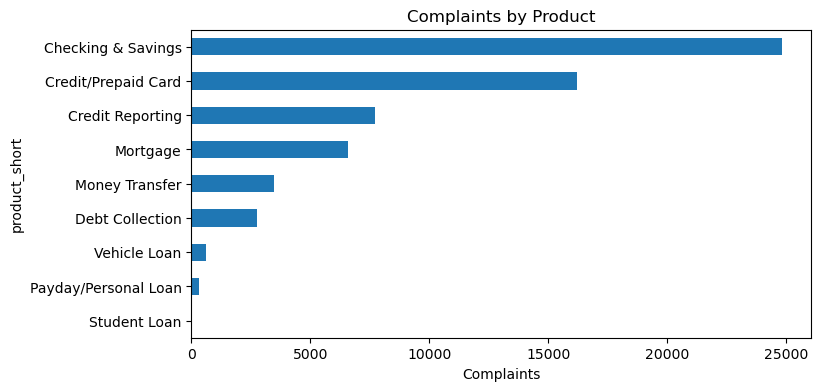

In [73]:
product_counts = df["product_short"].value_counts()
product_pct = (product_counts / len(df) * 100).round(2)
print(pd.DataFrame({"complaints": product_counts, "share_pct": product_pct}))
product_counts.sort_values().plot(kind="barh", figsize=(8, 4), title="Complaints by Product")
plt.xlabel("Complaints")
plt.show()

### 7.2 Top 10 Issues
What are the root causes?

issue
Managing an account                                                                 15109
Incorrect information on your report                                                 4931
Problem with a purchase shown on your statement                                      4415
Closing an account                                                                   2953
Trouble during payment process                                                       2827
Opening an account                                                                   2725
Problem with a lender or other company charging your account                         2493
Fraud or scam                                                                        1987
Struggling to pay mortgage                                                           1904
Problem with a credit reporting company's investigation into an existing problem     1876
Name: count, dtype: int64


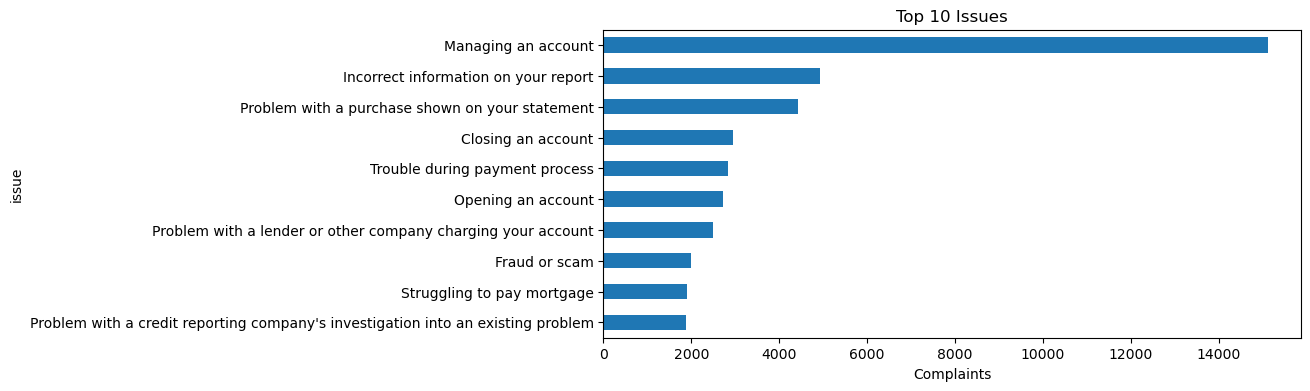

In [74]:
top_issues = df["issue"].value_counts().head(10)
print(top_issues)
top_issues.sort_values().plot(kind="barh", figsize=(9, 4), title="Top 10 Issues")
plt.xlabel("Complaints")
plt.show()

### 7.3 SLA Breach (Late Rate) by Product
Late rate = late ÷ closed. The overall rate can hide risk inside single products. The red line is an **assumed** 5% target, not a regulatory rule.

                      closed_complaints  late  late_rate_pct
product_short                                               
Debt Collection                    2687   173           6.44
Credit Reporting                   7520   475           6.32
Vehicle Loan                        617    33           5.35
Credit/Prepaid Card               15785   689           4.36
Money Transfer                     3384   140           4.14
Checking & Savings                24104   867           3.60
Payday/Personal Loan                331    10           3.02
Mortgage                           6555    16           0.24
Student Loan                         39     0           0.00

Overall late rate %: 3.94


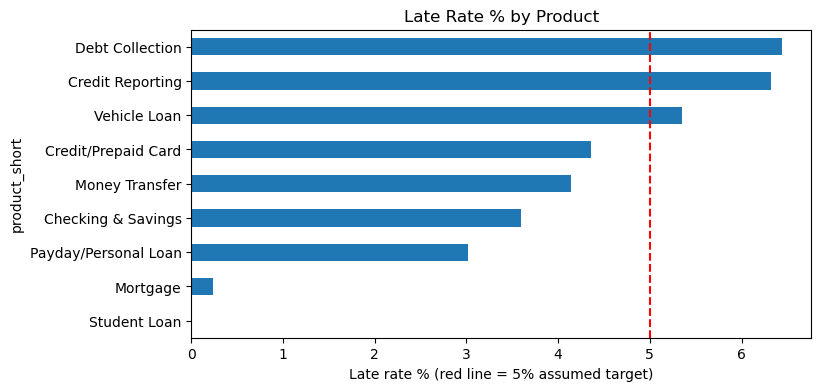

In [53]:
sla = closed.groupby("product_short").agg(
    closed_complaints=("is_late", "count"),
    late=("is_late", "sum")
)
sla["late_rate_pct"] = (sla["late"] / sla["closed_complaints"] * 100).round(2)
sla = sla.sort_values("late_rate_pct", ascending=False)
print(sla)
print("\nOverall late rate %:", round(closed["is_late"].mean() * 100, 2))

sla["late_rate_pct"].sort_values().plot(kind="barh", figsize=(8, 4), title="Late Rate % by Product")
plt.axvline(5, color="red", linestyle="--")
plt.xlabel("Late rate % (red line = 5% assumed target)")
plt.show()

### 7.4 Relief Rate by Product
Monetary relief is a proxy for remediation cost.

                      closed_complaints  any_relief_pct  monetary_relief_pct
product_short                                                               
Checking & Savings                24104           38.45                33.30
Credit/Prepaid Card               15785           40.67                30.40
Money Transfer                     3384           19.95                18.74
Payday/Personal Loan                331           20.85                12.69
Mortgage                           6555           24.81                11.44
Vehicle Loan                        617           22.69                 9.89
Debt Collection                    2687           11.91                 4.13
Credit Reporting                   7520           19.30                 3.63
Student Loan                         39            5.13                 2.56


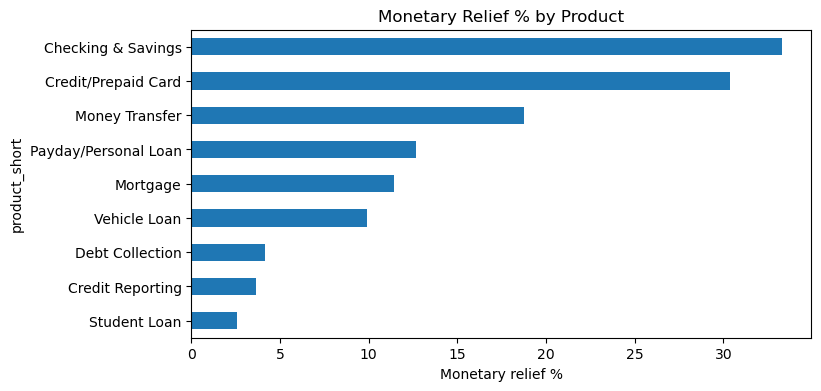

In [54]:
relief = closed.groupby("product_short").agg(
    closed_complaints=("complaint_id", "count"),
    any_relief_pct=("has_any_relief", "mean"),
    monetary_relief_pct=("has_monetary_relief", "mean")
)
relief["any_relief_pct"] = (relief["any_relief_pct"] * 100).round(2)
relief["monetary_relief_pct"] = (relief["monetary_relief_pct"] * 100).round(2)
relief = relief.sort_values("monetary_relief_pct", ascending=False)
print(relief)

relief["monetary_relief_pct"].sort_values().plot(kind="barh", figsize=(8, 4), title="Monetary Relief % by Product")
plt.xlabel("Monetary relief %")
plt.show()

### 7.5 Top 10 States
Raw counts, not adjusted for population. A per-100k rate is added later in SQL.

state
CA    13709
FL     6488
TX     4686
NY     4442
GA     2921
NJ     2664
IL     2270
MA     2141
MD     1959
VA     1731
Name: count, dtype: int64

Top 4 states share %: 46.91
Top state vs next state: 2.11 x


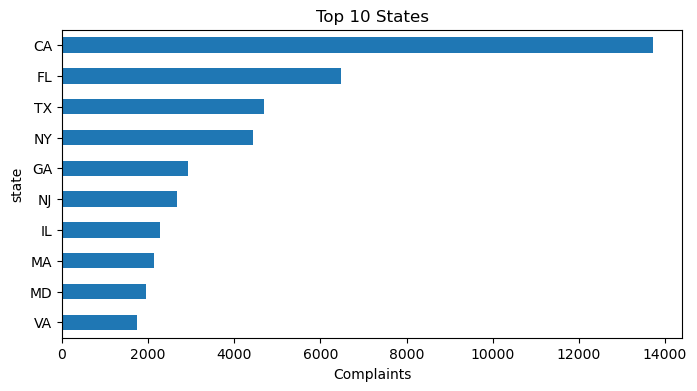

In [55]:
state_counts = df["state"].value_counts()
print(state_counts.head(10))
print("\nTop 4 states share %:", round(state_counts.head(4).sum() / len(df) * 100, 2))
print("Top state vs next state:", round(state_counts.iloc[0] / state_counts.iloc[1], 2), "x")
state_counts.head(10).sort_values().plot(kind="barh", figsize=(8, 4), title="Top 10 States")
plt.xlabel("Complaints")
plt.show()

### 7.6 Channel Mix
How do consumers submit complaints?

channel
Web             72.66
Referral        17.22
Phone            7.49
Postal mail      2.11
Fax              0.37
Web Referral     0.14
Email            0.00
Name: proportion, dtype: float64


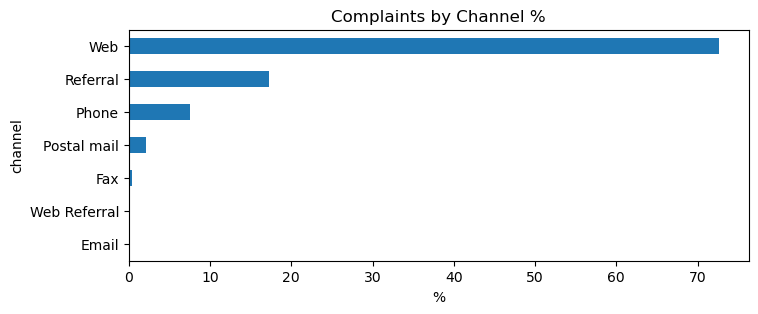

In [56]:
channel_pct = (df["channel"].value_counts(normalize=True) * 100).round(2)
print(channel_pct)
channel_pct.sort_values().plot(kind="barh", figsize=(8, 3), title="Complaints by Channel %")
plt.xlabel("%")
plt.show()

### 7.7 Yearly Trend
Data starts May 2017 and ends Aug 2023, so 2017 and 2023 are partial. For a fair compare, use Jan to Aug only, 2018 to 2023.

All months per year (2017 and 2023 partial):
year
2017     5394
2018     7872
2019     7075
2020     8942
2021    11149
2022    12953
2023     9131
Name: count, dtype: int64

Jan-Aug only, 2018-2023 (fair compare):
year
2018    5663
2019    4546
2020    5450
2021    7595
2022    8350
2023    9131
dtype: int64


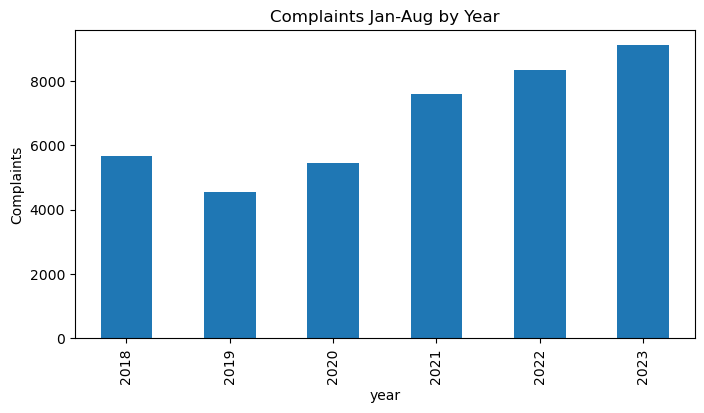

In [59]:
yearly = df["year"].value_counts().sort_index()
print("All months per year (2017 and 2023 partial):")
print(yearly)

fair = df[(df["month"] <= 8) & (df["year"] >= 2018)].groupby("year").size()
print("\nJan-Aug only, 2018-2023 (fair compare):")
print(fair)

fair.plot(kind="bar", figsize=(8, 4), title="Complaints Jan-Aug by Year")
plt.ylabel("Complaints")
plt.show()

### 7.8 Seasonality
Use full years only, 2018 to 2022.

Quarter share % (2018-2022):
quarter
1    23.58
2    24.93
3    25.95
4    25.54
Name: proportion, dtype: float64


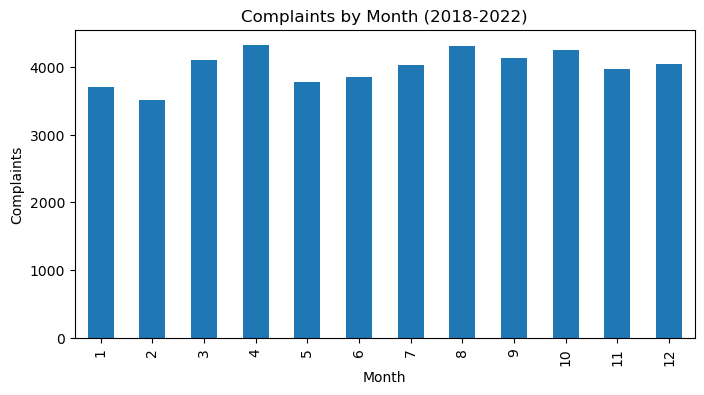

In [60]:
full_years = df[df["year"].between(2018, 2022)]

print("Quarter share % (2018-2022):")
print((full_years["quarter"].value_counts(normalize=True).sort_index() * 100).round(2))

full_years["month"].value_counts().sort_index().plot(kind="bar", figsize=(8, 4), title="Complaints by Month (2018-2022)")
plt.xlabel("Month")
plt.ylabel("Complaints")
plt.show()

### 7.9 Root Cause in Top Products
What issues drive complaints inside the products that matter most?

In [61]:
for p in ["Checking & Savings", "Credit/Prepaid Card", "Money Transfer"]:
    sub = df[df["product_short"] == p]
    print("\n---", p, "---")
    print((sub["issue"].value_counts(normalize=True).head(5) * 100).round(2))


--- Checking & Savings ---
issue
Managing an account                                             60.89
Closing an account                                              11.90
Opening an account                                              10.98
Problem with a lender or other company charging your account    10.05
Problem caused by your funds being low                           5.36
Name: proportion, dtype: float64

--- Credit/Prepaid Card ---
issue
Problem with a purchase shown on your statement    27.26
Getting a credit card                              11.53
Other features, terms, or problems                 10.08
Fees or interest                                    8.78
Problem when making payments                        8.20
Name: proportion, dtype: float64

--- Money Transfer ---
issue
Fraud or scam                                             56.50
Other transaction problem                                 16.54
Money was not available when promised                      7.53
Unauthor

### 7.10 Late Rate by Year
Is SLA performance getting better or worse? 2017 and 2023 are partial years.

year
2017     0.17
2018     0.15
2019     0.10
2020     0.69
2021    10.98
2022     4.38
2023     6.84
Name: is_late, dtype: float64


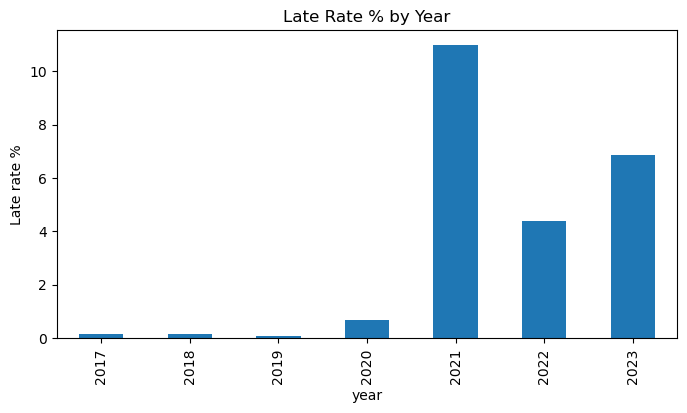

In [62]:
late_by_year = (closed.groupby("year")["is_late"].mean() * 100).round(2)
print(late_by_year)

late_by_year.plot(kind="bar", figsize=(8, 4), title="Late Rate % by Year")
plt.ylabel("Late rate %")
plt.show()

### 7.11 Late Rate by Channel
Ignore channels with very few complaints (Email has 2).

In [63]:
channel_sla = closed.groupby("channel").agg(
    closed_complaints=("is_late", "count"),
    late_rate_pct=("is_late", "mean")
)
channel_sla["late_rate_pct"] = (channel_sla["late_rate_pct"] * 100).round(2)
print(channel_sla.sort_values("late_rate_pct", ascending=False))

              closed_complaints  late_rate_pct
channel                                       
Web Referral                 83           4.82
Web                       44127           4.34
Phone                      4552           3.78
Referral                  10715           2.62
Postal mail                1310           2.14
Fax                         233           0.43
Email                         2           0.00


## 8. Key Findings
1. **Product concentration:** Checking & Savings (39.69%) + Credit/Prepaid Card (25.91%) = 65.6% of all complaints.
2. **Top issue:** Managing an account, 15,109 complaints (24.2% of all).
3. **SLA hides risk:** overall late rate is 3.94%, below an assumed 5% target. But Debt Collection (6.44%), Credit Reporting (6.32%), and Vehicle Loan (5.35%) are above it. Mortgage is only 0.24%.
4. **Remediation cost:** Checking & Savings (33.30%) and Credit/Prepaid Card (30.40%) have the highest monetary relief rates and drive about 87% of all monetary relief.
5. **Geography:** CA, FL, TX, NY = 46.9% of complaints. CA is 2.1x the next state (FL). Counts are raw, not per capita.
6. **Seasonality is weak:** 2018-2022 quarters range from 23.6% to 25.9%. Staff evenly, with a small Q3 buffer.
7. **Channel:** Web = 72.66% of submissions.

*Add after you read outputs 8.9 and 8.10:*
- Root cause inside Checking & Savings:
- Money Transfer top issue:
- Late rate trend by year:

## Data Notes
- Data runs 2017-05-01 to 2023-08-28. 2017 and 2023 are partial years.
- Blank `timely_response` = in progress (1,494). Timely, late, and relief rates use closed complaints (61,022).
- 435 complaints have intake lag over 30 days (max 275 days). Use median, not mean.
- Small samples: Student Loan (39), Payday/Personal Loan (333), Vehicle Loan (633). No strong conclusions from their rates.
- 5% late-rate line is an assumed internal target.
- Source data: public CFPB complaints, not an internal bank log.

In [75]:
df.to_csv("complaints_clean.csv", index=False)
print(df.shape)
print(df.columns.tolist())

(62516, 25)
['complaint_id', 'channel', 'date_submitted', 'date_received', 'state', 'product', 'sub_product', 'issue', 'sub_issue', 'company_public_response', 'company_response', 'timely_response', 'year', 'quarter', 'month', 'month_name', 'year_month', 'intake_lag_days', 'is_in_progress', 'is_timely', 'is_late', 'has_monetary_relief', 'has_non_monetary_relief', 'has_any_relief', 'product_short']
